# Version 2 Exploratory Analysis

This notebook is the authoritative exploratory analysis for the synthetic Version 2 temporal retention data. Notebook 18 is retained only as historical Version 1 evidence.

Outcome relationships below use the training snapshot only. Validation and final-test outcomes are not used for EDA, and current future outcomes remain unknown.

**Portfolio navigation:** [Notebook index](README.md) · [V2 EDA report](../docs/v2_exploratory_analysis.md) · [Next: V2 department history](38_v2_department_history.ipynb)


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
OUTPUT = PROJECT_ROOT / "data" / "processed" / "v2_exploratory_analysis"
print("Loaded aggregate Version 2 exploratory evidence.")


Loaded aggregate Version 2 exploratory evidence.


## Authoritative Version 2 populations

The temporal panel contains repeated employee-snapshot observations. Rows are not interchangeable with unique employees.


In [2]:
profile = pd.read_csv(OUTPUT / "dataset_profile.csv")
display(profile)


,population,rows,unique_employees,columns,snapshot_count,employees_repeated_across_snapshots,outcome_role
0,Historical temporal panel,16673,7745,52,3,5414,Training outcomes only for EDA
1,Current active scoring population,7409,7409,52,1,0,Future outcomes unknown


## Temporal structure and review availability

Only the training row contains an exploratory attrition rate. Reserved-period rates are intentionally blank here and are discussed later in the post-evaluation prior-shift audit.


In [3]:
periods = pd.read_csv(OUTPUT / "period_structure.csv")
display(periods)


,snapshot_sequence,period,eda_role,rows,unique_employees,missing_review_rows,missing_review_rate,attrition_rate_used_for_eda
0,1,2023 training snapshot,training_eda,4303,4303,2916,0.677667,0.096212
1,2,2024 validation snapshot,structure_only,5625,5625,2489,0.442489,NaN
2,3,2025 final-test snapshot,structure_only,6745,6745,1821,0.269978,NaN


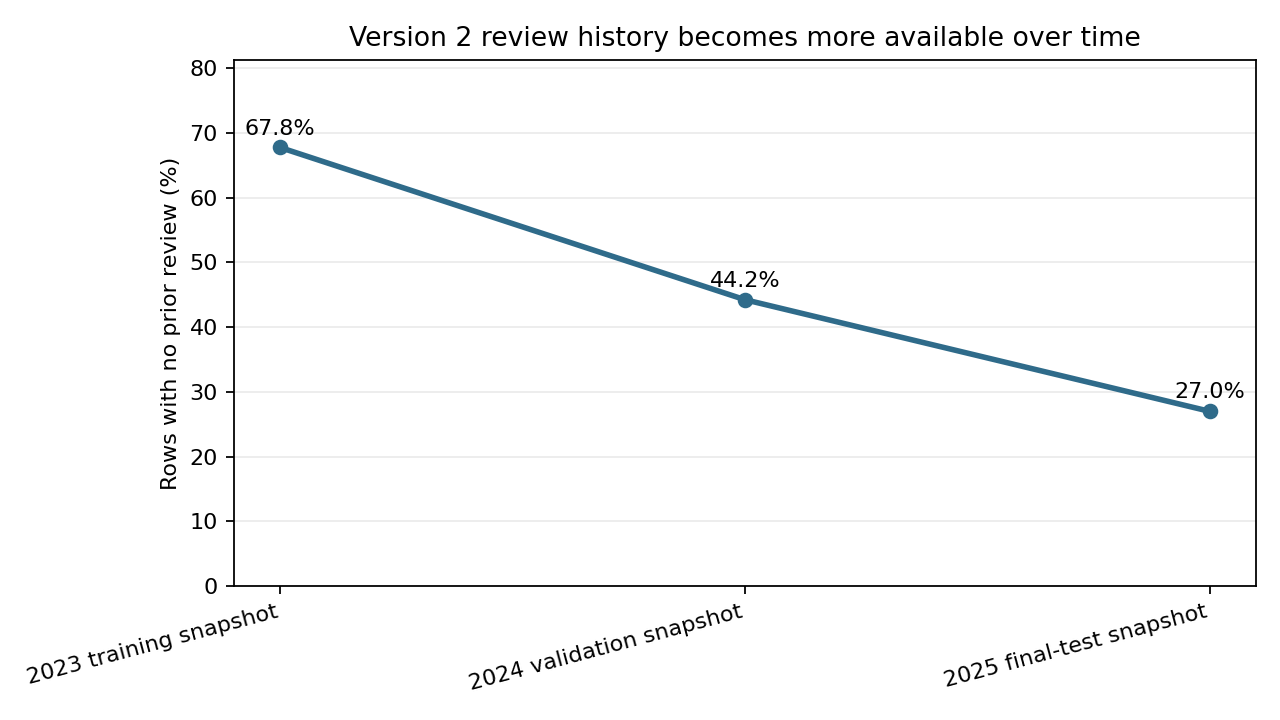

In [4]:
display(Image(filename=OUTPUT / "review_availability_over_time.png"))


## Review-history missingness: V1 versus V2

The old 15.07% versus 6.36% Version 1 result is not reused. Version 2 training shows 9.81% versus 9.23%, a much smaller 0.58 percentage-point difference.


In [5]:
review = pd.read_csv(OUTPUT / "training_review_missingness.csv")
comparison = pd.read_csv(OUTPUT / "v1_v2_missingness_comparison.csv")
display(review)
display(comparison)


,no_prior_review,review_history,rows,positive_cases,attrition_rate,analysis_role
0,0,Prior review present,1387,128,0.092286,Training-only descriptive EDA
1,1,No prior review,2916,286,0.098080,Training-only descriptive EDA


,dataset,rows,missing_review_rows,missing_review_rate,missing_review_attrition_rate,review_present_attrition_rate,missing_minus_present_gap,authoritative_for_v2
0,Version 1 single snapshot,7386,1805,0.244400,0.15070,0.063600,0.087100,False
1,Version 2 training snapshot,4303,2916,0.677667,0.09808,0.092286,0.005794,True


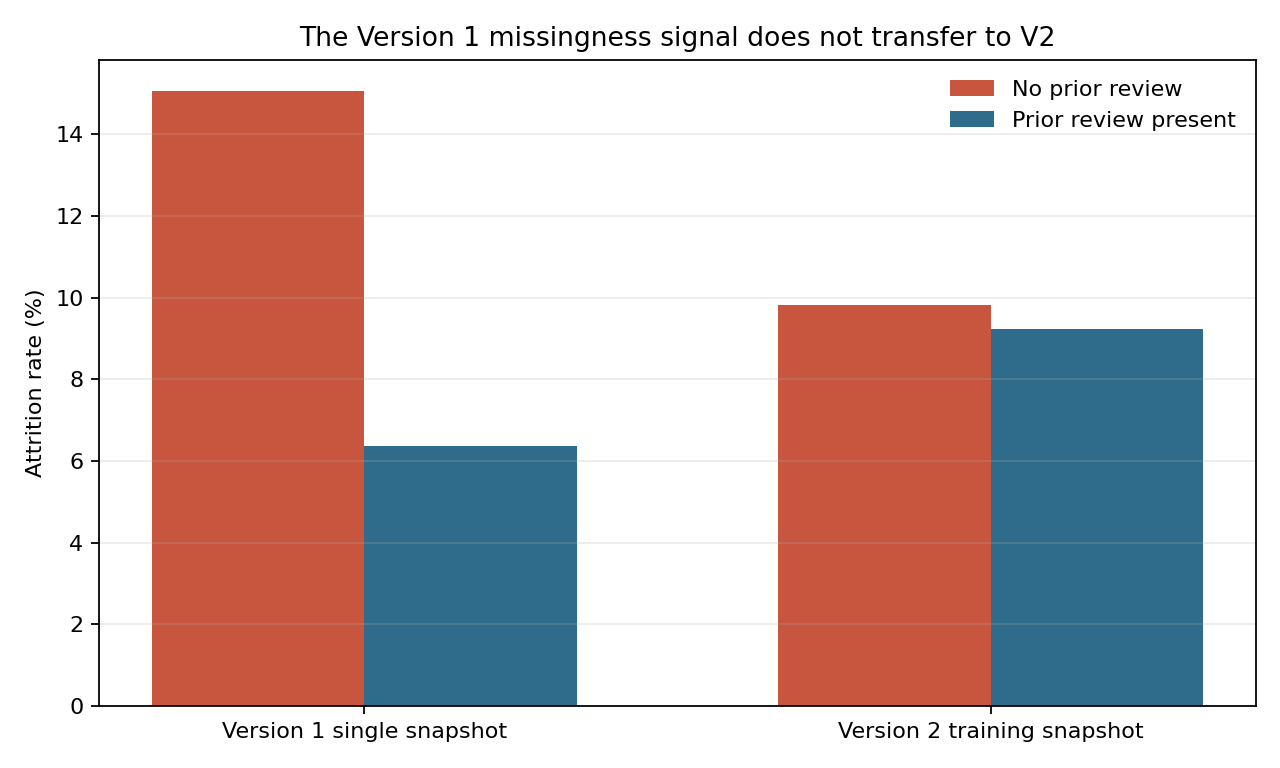

In [6]:
display(Image(filename=OUTPUT / "v1_v2_missingness_signal.png"))


## Training-period group patterns

These are unadjusted synthetic descriptions, not causal effects. Customer Support is highest at 16.62%; hourly employees are 14.48% versus 8.73% for salaried employees.


In [7]:
groups = pd.read_csv(OUTPUT / "training_group_rates.csv")
departments = groups[groups["dimension"].eq("department_name")].sort_values("attrition_rate", ascending=False)
display(departments)


,dimension,group,rows,positive_cases,attrition_rate,population_share,analysis_role
0,department_name,Customer Support,325,54,0.166154,0.075529,Training-only descriptive EDA
2,department_name,Finance,336,42,0.125000,0.078085,Training-only descriptive EDA
3,department_name,Human Resources,298,37,0.124161,0.069254,Training-only descriptive EDA
5,department_name,Manufacturing,1058,104,0.098299,0.245875,Training-only descriptive EDA
4,department_name,Information Technology,428,40,0.093458,0.099465,Training-only descriptive EDA
1,department_name,Engineering,876,68,0.077626,0.203579,Training-only descriptive EDA
6,department_name,Sales,451,35,0.077605,0.104811,Training-only descriptive EDA
7,department_name,Supply Chain,531,34,0.064030,0.123402,Training-only descriptive EDA


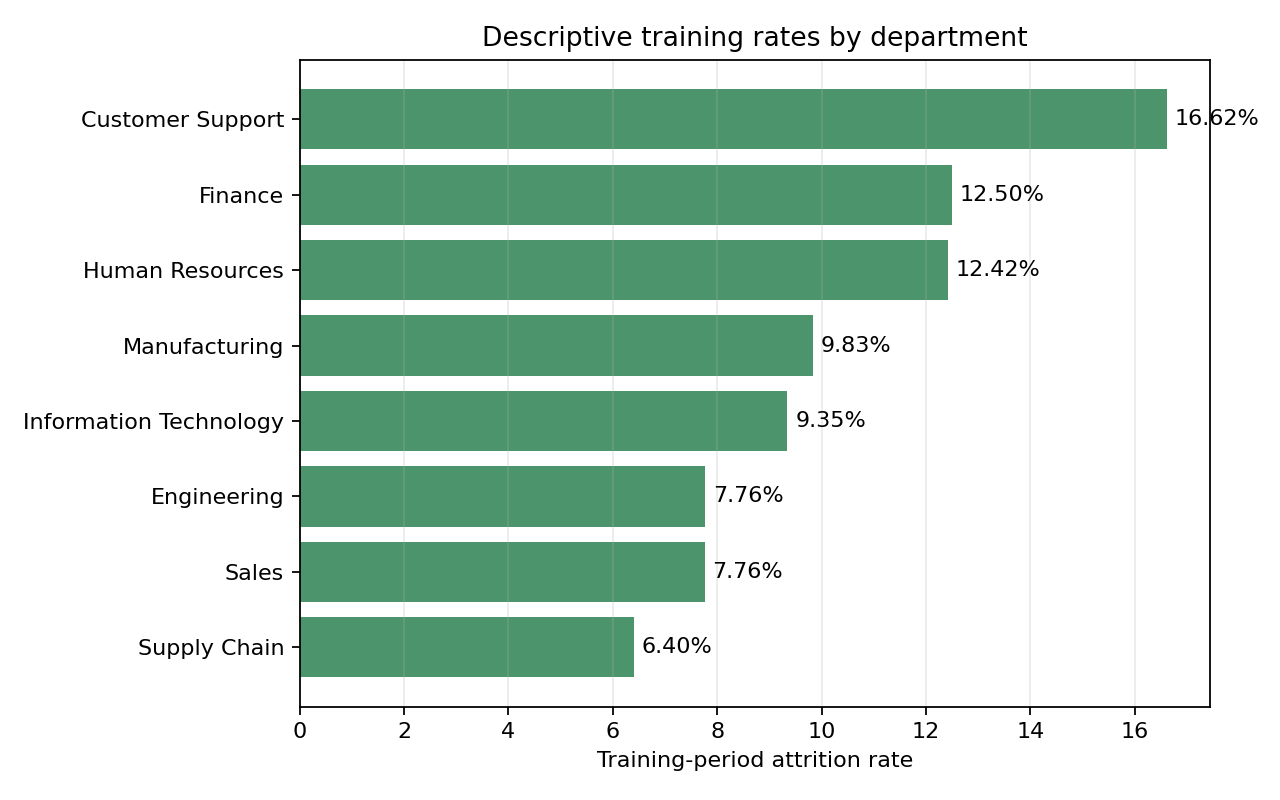

In [8]:
display(Image(filename=OUTPUT / "training_department_attrition.png"))


## Validation and boundaries

The audit verifies that the EDA describes Version 2, keeps V1 findings separate, uses only training outcomes for relationships, exports aggregate evidence, and changes no model or policy result.


In [9]:
checks = pd.read_csv(OUTPUT / "validation_checks.csv")
display(checks[["check", "status", "details"]])
assert checks["status"].eq("PASS").all()
print(f"Checks passed: {len(checks)}/{len(checks)}")


,check,status,details
0,Authoritative Version 2 populations reconcile,PASS,The EDA describes the same temporal population...
1,Snapshot row counts reconcile,PASS,"The temporal panel is not replaced by the 7,38..."
2,Review-missingness flag matches feature availa...,PASS,Missing review history is an explicit feature ...
3,Version 2 review availability reconciles,PASS,The V1 24.44% missingness rate is not presente...
4,Review availability is reported by snapshot,PASS,Review history accumulates as the synthetic wo...
5,Training-only missingness signal reconciles,PASS,"The V2 training gap is 0.58 points, not the V1..."
6,Reserved outcomes remain outside exploratory a...,PASS,Only training outcomes support pre-model descr...
7,Current outcomes remain unknown,PASS,Current scoring rows are not mislabeled with f...
8,V1 and V2 missingness findings remain separated,PASS,The strong V1 missingness association is not c...
9,Saved exploratory outputs are aggregate only,PASS,No employee-level outcome or score file is pro...


Checks passed: 11/11
